# Gaussian Processes Summer School

## Part 2: Spectral Mixtures

<a href="https://www.uc3m.es/"><img src="./uc3m.png" alt="Universidad Carlos III de Madrid" width="520"></a>

**Author:** [Pablo M. Olmos](https://olmos-pm.github.io/)

**Email:** [pamartin@ing.uc3m.es](mailto:pamartin@ing.uc3m.es)

---

### Categorical mixture of stationary Gaussian processes

This notebook uses `generate_gp_mixture.py` to sample curves from three locally periodic GP components, with periods $T \in \{1, 0.5, 0.25\}$ and angular frequencies $\omega = 2\pi/T$.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from generate_gp_mixture import generate_gp_mixture, locally_periodic_kernel

plt.style.use("seaborn-v0_8-whitegrid")

## Generate the dataset

### Hierarchical generative model

Let $x_1,\ldots,x_N$ be the common input grid and let $i=1,\ldots,n$ index independently generated signals. First, each complete signal chooses one latent component:

$$z_i\sim\operatorname{Categorical}(\pi_1,\pi_2,\pi_3).$$

Conditional on $z_i=m$, its latent function is drawn from component $m$:

$$f_i\mid z_i=m\sim\mathcal{GP}(0,k_m),$$

with the **true stationary locally periodic kernel**

$$k_m(x,x')=k_m(\tau)=\sigma_f^2\exp\!\left(-\frac{\tau^2}{2\ell_m^2}\right)\cos(\omega_m\tau),\qquad \tau=x-x',$$

where $\omega_m=2\pi/T_m$. The RBF factor is a smooth envelope and the cosine creates oscillation at the component frequency.

#### Intuition for the locally periodic kernel

The kernel is **stationary** because it depends only on the lag $\tau=x-x'$, not on the absolute locations. It is useful to read it as the product of two effects:

- $\cos(\omega_m\tau)$ specifies the preferred oscillation and repeats every $T_m=2\pi/\omega_m$.
- $\exp[-\tau^2/(2\ell_m^2)]$ is a memory envelope that gradually suppresses this periodic relationship as two locations move apart.

At zero lag, $k_m(0)=\sigma_f^2$, so $\sigma_f^2$ is the marginal signal variance. At half a period the cosine is $-1$, so a high value tends to correspond to a low value half a cycle later:

$$k_m(T_m/2)=-\sigma_f^2\exp\!\left(-\frac{T_m^2}{8\ell_m^2}\right).$$

After one complete period the covariance is positive again, but its magnitude has decayed:

$$k_m(T_m)=\sigma_f^2\exp\!\left(-\frac{T_m^2}{2\ell_m^2}\right).$$

Thus the model prefers locally sinusoidal behavior without requiring the same pattern to repeat forever. When $|\tau|\gg\ell_m$, the envelope is nearly zero and even points at the same nominal phase become almost unrelated. This is the main difference from a strictly periodic kernel, whose correlations repeat indefinitely.

The dimensionless ratio $\ell_m/T_m$ gives a rough count of how many cycles fit inside one correlation length. For this dataset:

| period $T_m$ | $\ell_m/T_m$ | interpretation |
|---:|---:|:---|
| $1.0$ | $0.6$ | less than one cycle per correlation length |
| $0.5$ | $1.2$ | about one coherent cycle |
| $0.25$ | $2.4$ | several rapid cycles before decorrelation |

Increasing $\ell_m$ produces longer, more regular wave trains. Decreasing it produces shorter oscillatory bursts with faster phase and amplitude drift. The latent GP paths remain smooth because both factors in the kernel are infinitely differentiable; the small independent observation noise is what adds visible point-to-point jitter.

#### Why this gives two Gaussian spectral bands: Bochner's theorem

Bochner's theorem states that a continuous stationary function $k(\tau)$ is a valid positive-semidefinite covariance kernel if and only if it is the Fourier transform of a finite non-negative measure $\mu$:

$$k(\tau)=\int_{\mathbb R}e^{i\omega\tau}\,\mu(d\omega).$$

For a real-valued stationary kernel, the measure is symmetric, so the imaginary sine terms cancel. Because $k_m(0)=\sigma_f^2$, the total mass of $\mu_m$ is $\sigma_f^2$. We can therefore write $\mu_m(d\omega)=\sigma_f^2p_m(\omega)d\omega$, where $p_m$ integrates to one:

$$k_m(\tau)=\sigma_f^2\int_{\mathbb R}e^{i\omega\tau}p_m(\omega)\,d\omega=\sigma_f^2\int_{\mathbb R}\cos(\omega\tau)p_m(\omega)\,d\omega.$$

The RBF envelope is the characteristic function of a zero-mean Gaussian frequency. If $\nu\sim\mathcal N(0,\ell_m^{-2})$, then

$$\mathbb E[e^{i\nu\tau}]=\exp\!\left(-\frac{\tau^2}{2\ell_m^2}\right).$$

Next, write the cosine carrier as two complex exponentials:

$$\cos(\omega_m\tau)=\tfrac12e^{i\omega_m\tau}+\tfrac12e^{-i\omega_m\tau}.$$

Multiplying the RBF envelope by this cosine shifts the zero-centered Gaussian spectrum to $+\omega_m$ and $-\omega_m$:

$$\frac{k_m(\tau)}{\sigma_f^2}=\tfrac12\mathbb E[e^{i(\nu+\omega_m)\tau}]+\tfrac12\mathbb E[e^{i(\nu-\omega_m)\tau}].$$

Hence the normalized spectral density is

$$p_m(\omega)=\tfrac12\mathcal N(\omega;\omega_m,\ell_m^{-2})+\tfrac12\mathcal N(\omega;-\omega_m,\ell_m^{-2}).$$

The two equal weights enforce the symmetry required for a real covariance. The centers $\pm\omega_m$ determine the oscillation frequency, while the spectral variance $\ell_m^{-2}$ determines each band's width: a larger $\ell_m$ gives narrower, more concentrated frequency bands and longer-lived oscillations; a smaller $\ell_m$ gives wider bands and faster loss of periodic coherence.

Finally, independent observation noise is added at every grid location:

$$y_{ij}=f_i(x_j)+\varepsilon_{ij},\qquad \varepsilon_{ij}\overset{\mathrm{iid}}\sim\mathcal N(0,\sigma_n^2).$$

The parameters used here are:

| component $m$ | period $T_m$ | frequency $\omega_m$ | lengthscale $\ell_m$ | output scale $\sigma_f^2$ | weight $\pi_m$ |
|---:|---:|---:|---:|---:|---:|
| 0 | $1$ | $2\pi$ | $0.6$ | $1$ | $1/3$ |
| 1 | $0.5$ | $4\pi$ | $0.6$ | $1$ | $1/3$ |
| 2 | $0.25$ | $8\pi$ | $0.6$ | $1$ | $1/3$ |

The observation standard deviation is $\sigma_n=0.05$, hence $\sigma_n^2=0.0025$.

### How the code samples each signal

For each component we construct

$$[K_m]_{jk}=k_m(x_j,x_k),$$

computes one stabilized Cholesky factor

$$L_mL_m^\top=K_m+\delta I,$$

and, after drawing $z_i=m$, samples

$$\xi_i\sim\mathcal N(0,I),\qquad \mathbf f_i=L_m\xi_i,\qquad \mathbf y_i=\mathbf f_i+\boldsymbol\varepsilon_i.$$

The small $\delta=10^{-8}$ is numerical Cholesky jitter; it is distinct from the visible observation noise $\sigma_n=0.05$. The code factorizes each of the three covariance matrices once and samples all signals assigned to that component in a batch.

An approximate RFF generator could instead draw frequencies from $p_m(\omega)$ and sample a random linear combination of paired sine/cosine features. That is **not** how this database is produced: RFFs are introduced later only to approximate the RBF kernel of the fitted GP.

In [111]:
seed = 7
n_curves = 300
x = np.linspace(0.0, 4.0, 200)
periods = np.array([1.0, 0.5, 0.25])
frequencies = 2.0 * np.pi / periods
lengthscales = np.array([0.6, 0.6, 0.6])
mixture_weights = np.array([1 / 3, 1 / 3, 1 / 3])
noise_std = 0.05

curves, labels = generate_gp_mixture(
    x=x,
    n_curves=n_curves,
    periods=periods,
    lengthscales=lengthscales,
    mixture_weights=mixture_weights,
    variance=1.0,
    noise_std=noise_std,
    seed=seed,
)

counts = np.bincount(labels, minlength=len(periods))
print(f"Dataset shape: {curves.shape}")
for component, (period, frequency, count) in enumerate(zip(periods, frequencies, counts)):
    print(
        f"Component {component}: T={period:g}, omega={frequency:.3f}, "
        f"curves={count}"
    )

Dataset shape: (300, 200)
Component 0: T=1, omega=6.283, curves=100
Component 1: T=0.5, omega=12.566, curves=102
Component 2: T=0.25, omega=25.133, curves=98


## Signals sampled from the mixture

Each color identifies the latent categorical component that generated the signal.

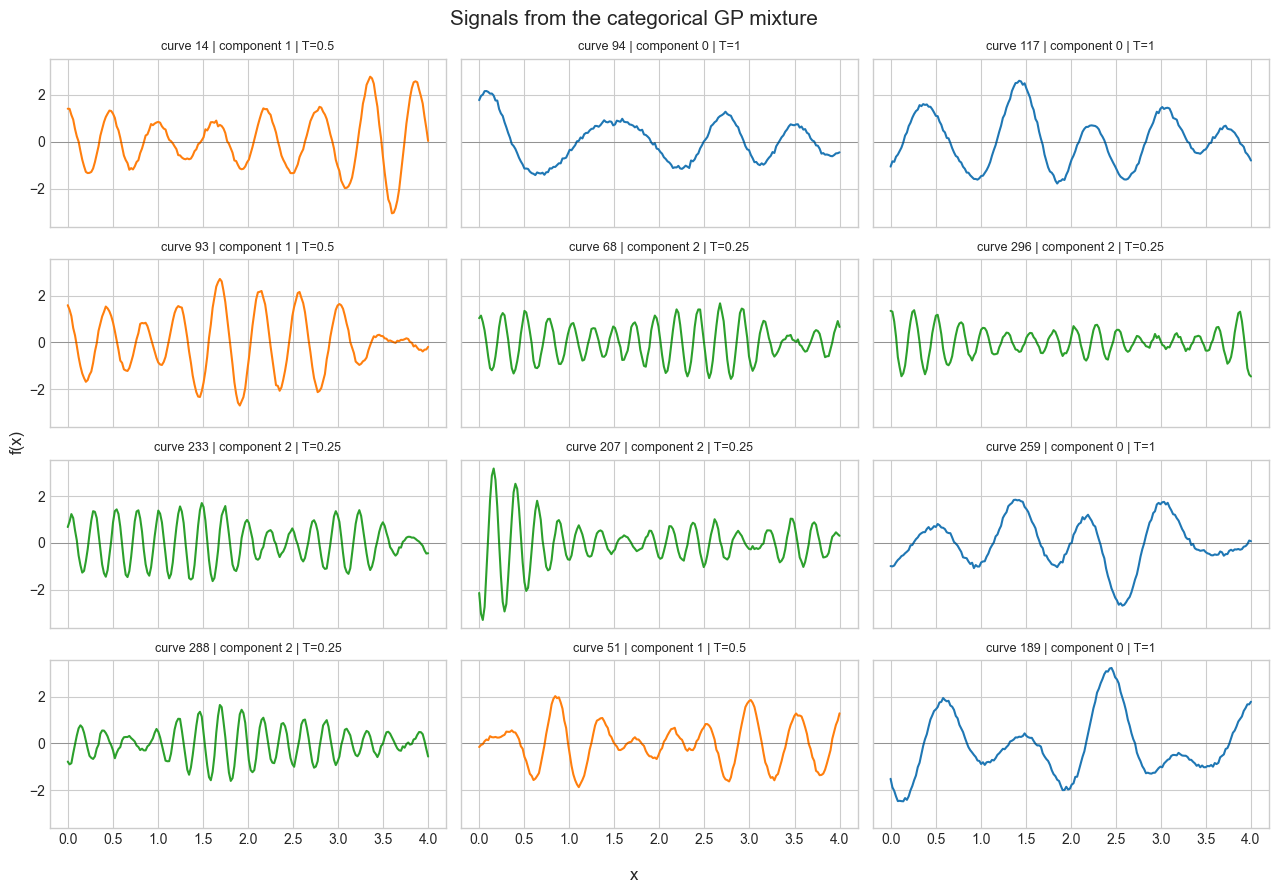

In [112]:
colors = plt.colormaps["tab10"](np.arange(len(periods)))
rng = np.random.default_rng(seed + 1)
shown = rng.choice(n_curves, size=12, replace=False)

fig, axes = plt.subplots(4, 3, figsize=(13, 9), sharex=True, sharey=True)
for ax, index in zip(axes.flat, shown):
    component = labels[index]
    ax.plot(x, curves[index], color=colors[component], linewidth=1.5)
    ax.set_title(
        f"curve {index} | component {component} | T={periods[component]:g}",
        fontsize=9,
    )
    ax.axhline(0.0, color="black", linewidth=0.5, alpha=0.4)

fig.supxlabel("x")
fig.supylabel("f(x)")
fig.suptitle("Signals from the categorical GP mixture", fontsize=15)
fig.tight_layout()
plt.show()

## Signals grouped by mixture component

Grouping makes the different oscillation rates easier to see.

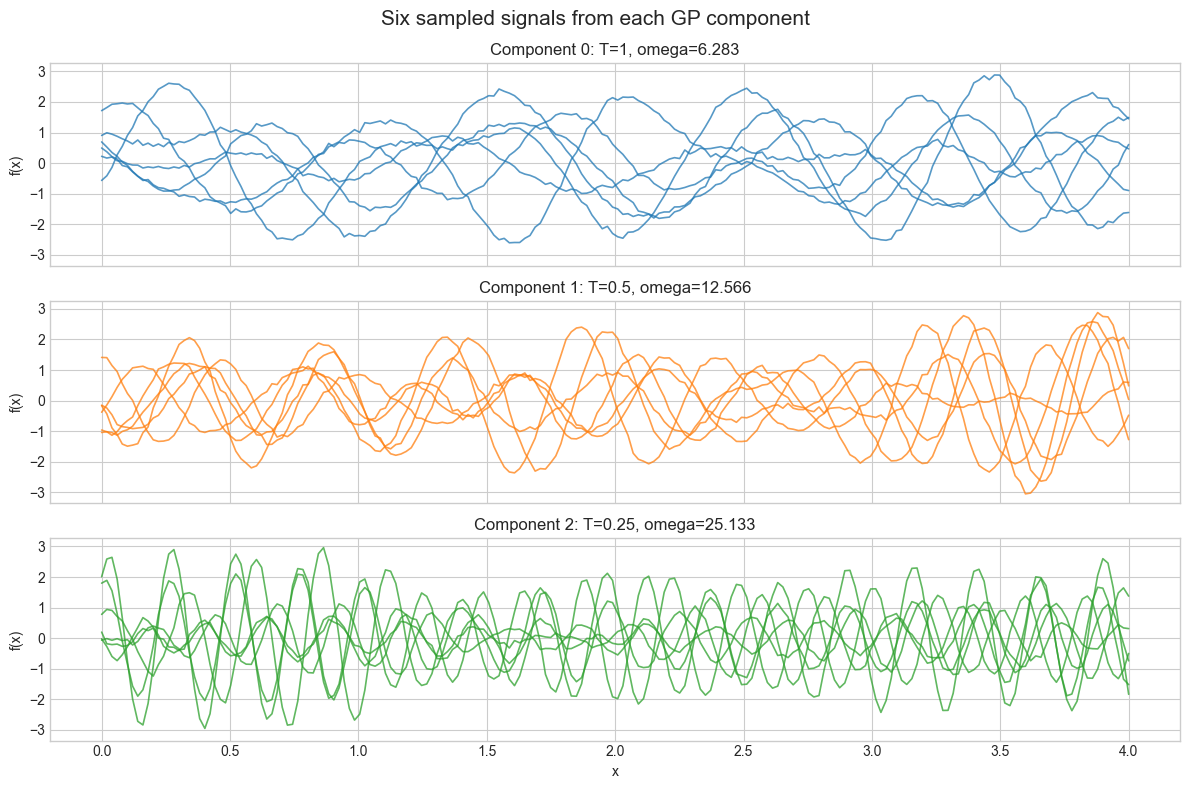

In [113]:
fig, axes = plt.subplots(len(periods), 1, figsize=(12, 8), sharex=True, sharey=True)
for component, ax in enumerate(axes):
    component_indices = np.flatnonzero(labels == component)[:6]
    for index in component_indices:
        ax.plot(x, curves[index], color=colors[component], alpha=0.75, linewidth=1.2)
    ax.set_title(
        f"Component {component}: T={periods[component]:g}, "
        f"omega={frequencies[component]:.3f}"
    )
    ax.set_ylabel("f(x)")

axes[-1].set_xlabel("x")
fig.suptitle("Six sampled signals from each GP component", fontsize=15)
fig.tight_layout()
plt.show()

## Component covariance functions

Because the kernels are stationary, each covariance depends only on the lag $\tau$.

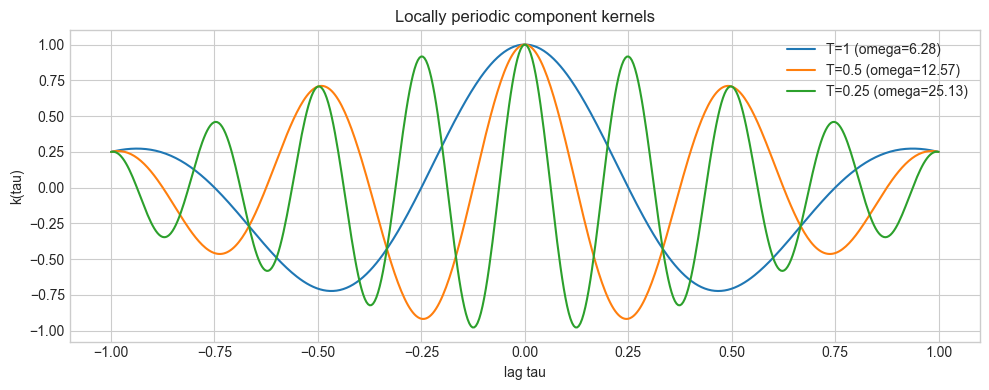

In [114]:
lags = np.linspace(-1.0, 1.0, 500)

fig, ax = plt.subplots(figsize=(10, 4))
for component, (period, frequency, lengthscale) in enumerate(
    zip(periods, frequencies, lengthscales)
):
    # Evaluating against x=0 gives k(tau) from the same kernel function
    # used to construct the GP covariance matrices.
    paired_points = np.concatenate(([0.0], lags))
    covariance = locally_periodic_kernel(
        paired_points, frequency=frequency, lengthscale=lengthscale
    )
    ax.plot(
        lags,
        covariance[0, 1:],
        color=colors[component],
        label=f"T={period:g} (omega={frequency:.2f})",
    )

ax.set(title="Locally periodic component kernels", xlabel="lag tau", ylabel="k(tau)")
ax.legend()
fig.tight_layout()
plt.show()

## Population GP fits: exact RBF versus random Fourier features

We now split entire curves into training and test partitions. All curves in the training partition contribute to one shared set of GP hyperparameters. The curves remain independent realizations; the component labels are not provided to either model.

### RBF kernel

The exact model uses

$$k_{\mathrm{RBF}}(x,x') = \sigma_f^2 \exp\!\left[-\frac{(x-x')^2}{2\ell^2}\right],$$

where $\ell$ is the lengthscale and $\sigma_f^2$ is the output scale (signal variance). Observations follow $y=f(x)+\varepsilon$ with $\varepsilon\sim\mathcal N(0,\sigma_n^2)$, so the fitted parameters are the mean, $\ell$, $\sigma_f^2$, and noise variance $\sigma_n^2$.

### Random Fourier feature approximation

The RBF spectral distribution is Gaussian: $\omega_d\sim\mathcal N(0,\ell^{-2})$. Drawing $D=L/2$ frequencies gives the paired feature map

$$z(x)=\sqrt{\frac{1}{D}}\,[\cos(\omega_1x),\sin(\omega_1x),\ldots,\cos(\omega_Dx),\sin(\omega_Dx)]^\top,$$

and therefore

$$k_{\mathrm{RBF}}(x,x') \approx \sigma_f^2 z(x)^\top z(x').$$

Thus $D=L/2$ sampled frequencies produce $L$ total sine/cosine features. The RFF model learns the same mean, lengthscale, output scale, and noise variance as the exact RBF model; only its covariance evaluation is approximated. This section requires PyTorch and GPyTorch.

In [115]:
import torch

from train_gp_models import (
    as_gp_tensors,
    build_rbf_gp,
    build_rff_gp,
    build_symmetric_spectral_mixture_rff_gp,
    learned_hyperparameters,
    learned_spectral_mixture_parameters,
    mean_negative_log_likelihood,
    predict_sparse_signal,
    train_shared_gp,
)

torch.manual_seed(seed)

### Train/test partition

The split is performed over signals, not over input locations. Consequently, no part of a test signal is used to learn the population hyperparameters.

In [116]:
split_rng = np.random.default_rng(seed + 2)
permutation = split_rng.permutation(n_curves)
n_train = int(0.8 * n_curves)
train_indices = permutation[:n_train]
test_indices = permutation[n_train:]

train_curves = curves[train_indices]
train_labels = labels[train_indices]
test_curves = curves[test_indices]
test_labels = labels[test_indices]
train_x_tensor, train_curves_tensor = as_gp_tensors(x, train_curves)

print(f"Training curves: {len(train_curves)}")
print(f"Test curves: {len(test_curves)}")

Training curves: 240
Test curves: 60


### Exact RBF fit

This model evaluates the full RBF covariance matrix. Its shared hyperparameters maximize the average marginal likelihood over the complete training partition.

In [117]:
rbf_model, rbf_likelihood = build_rbf_gp(
    train_x_tensor,
    train_curves_tensor,
    initial_lengthscale=0.2,
    initial_outputscale=1.0,
    initial_noise=noise_std**2,
)
rbf_losses = train_shared_gp(
    rbf_model,
    rbf_likelihood,
    train_x_tensor,
    train_curves_tensor,
    num_steps=75,
    learning_rate=0.05,
    print_every=15,
)
print("Exact RBF:", learned_hyperparameters(rbf_model, rbf_likelihood))

step    1/75 | loss=55.9440 | ell=0.1911 | scale=1.0319 | noise=0.00263
step   15/75 | loss=-0.3121 | ell=0.1103 | scale=1.4610 | noise=0.00408
step   30/75 | loss=-0.5910 | ell=0.0905 | scale=1.6424 | noise=0.00455
step   45/75 | loss=-0.5828 | ell=0.0862 | scale=1.6908 | noise=0.00463
step   60/75 | loss=-0.5809 | ell=0.0854 | scale=1.7009 | noise=0.00461
step   75/75 | loss=-0.5829 | ell=0.0855 | scale=1.7004 | noise=0.00456
Exact RBF: {'mean': -0.0005308325053192675, 'lengthscale': 0.08547389507293701, 'outputscale': 1.7004258632659912, 'noise': 0.004562699235975742}


### Component-specific versus shared RBF parameters

For reference, the true component kernel is $k_m(\tau)=\exp[-\tau^2/(2\ell_m^2)]\cos(\omega_m\tau)$ with envelope lengthscale $\ell_m=0.6$, output scale $1$, and observation-noise variance $0.05^2=0.0025$. It is **not** a pure RBF because of the cosine carrier. Consequently, the component-wise RBF fits below are effective approximations rather than recovery of the true generating kernel.

We fit one diagnostic RBF to the training curves from each known component, then compare those parameters with the single shared fit above. The labels are used only to construct this explanatory table; the shared model itself never sees them. Here, “amortized” means that one parameter set maximizes the average marginal likelihood over all training curves.

For each component, we also evaluate the component-specific RBF and the amortized RBF on exactly the same curves. NLL is the negative log marginal likelihood averaged over curves and normalized per observed grid point, so smaller is better. The NLL gap is $\mathrm{NLL}_{\mathrm{amortized}}-\mathrm{NLL}_{\mathrm{own}}$; a positive gap measures the cost of replacing that component's specialized parameters with one population-wide parameter set.

In [118]:
import pandas as pd
from IPython.display import display

component_fit_rows = []
component_fit_steps = 75

for component in range(len(periods)):
    component_curves = train_curves[train_labels == component]
    component_x_tensor, component_curves_tensor = as_gp_tensors(x, component_curves)
    component_model, component_likelihood = build_rbf_gp(
        component_x_tensor,
        component_curves_tensor,
        initial_lengthscale=0.2,
        initial_outputscale=1.0,
        initial_noise=noise_std**2,
    )
    train_shared_gp(
        component_model,
        component_likelihood,
        component_x_tensor,
        component_curves_tensor,
        num_steps=component_fit_steps,
        learning_rate=0.05,
        print_every=0,
    )
    fitted = learned_hyperparameters(component_model, component_likelihood)
    own_fit_nll = mean_negative_log_likelihood(
        component_model, component_likelihood,
        component_x_tensor, component_curves_tensor,
    )
    amortized_nll = mean_negative_log_likelihood(
        rbf_model, rbf_likelihood,
        component_x_tensor, component_curves_tensor,
    )
    component_fit_rows.append({
        "fit": f"Component {component} only",
        "generator period T": periods[component],
        "generator frequency omega": frequencies[component],
        "training curves": len(component_curves),
        "mean": fitted["mean"],
        "RBF lengthscale ell": fitted["lengthscale"],
        "output scale sigma_f^2": fitted["outputscale"],
        "noise variance sigma_n^2": fitted["noise"],
        "own-fit mean NLL": own_fit_nll,
        "amortized mean NLL (same curves)": amortized_nll,
        "NLL gap (amortized - own)": amortized_nll - own_fit_nll,
    })

shared = learned_hyperparameters(rbf_model, rbf_likelihood)
shared_all_nll = mean_negative_log_likelihood(
    rbf_model, rbf_likelihood, train_x_tensor, train_curves_tensor
)
component_fit_rows.append({
    "fit": "All components (shared/amortized)",
    "generator period T": np.nan,
    "generator frequency omega": np.nan,
    "training curves": len(train_curves),
    "mean": shared["mean"],
    "RBF lengthscale ell": shared["lengthscale"],
    "output scale sigma_f^2": shared["outputscale"],
    "noise variance sigma_n^2": shared["noise"],
    "own-fit mean NLL": shared_all_nll,
    "amortized mean NLL (same curves)": shared_all_nll,
    "NLL gap (amortized - own)": 0.0,
})

rbf_parameter_table = pd.DataFrame(component_fit_rows).set_index("fit")
display(
    rbf_parameter_table.style.format(
        precision=5, na_rep="—", thousands=",")
    .set_caption("Component-specific and population-shared RBF fits")
)

,generator period T,generator frequency omega,training curves,mean,RBF lengthscale ell,output scale sigma_f^2,noise variance sigma_n^2,own-fit mean NLL,amortized mean NLL (same curves),NLL gap (amortized - own)
fit,,,,,,,,,,
Component 0 only,1.00000,6.28319,75,-0.02185,0.28353,2.46103,0.00245,-1.19017,-0.68050,0.50967
Component 1 only,0.50000,12.56637,84,-0.00271,0.15221,1.72974,0.00248,-0.94462,-0.66255,0.28208
Component 2 only,0.25000,25.13274,81,-0.00301,0.08379,1.73521,0.00469,-0.41756,-0.41027,0.00729
All components (shared/amortized),—,—,240,-0.00053,0.08547,1.70043,0.00456,-0.58302,-0.58302,0.00000


### Random Fourier feature fit

Here $L=128$, so GPyTorch samples $L/2=64$ frequencies and constructs 128 paired sine/cosine features. The optimization setup is otherwise the same as for the exact RBF model.

In [119]:
L = 128
rff_model, rff_likelihood = build_rff_gp(
    train_x_tensor,
    train_curves_tensor,
    num_features=L,
    seed=seed + 3,
    initial_lengthscale=0.2,
    initial_outputscale=1.0,
    initial_noise=noise_std**2,
)
rff_losses = train_shared_gp(
    rff_model,
    rff_likelihood,
    train_x_tensor,
    train_curves_tensor,
    num_steps=75,
    learning_rate=0.05,
    print_every=15,
)
print("RFF approximation:", learned_hyperparameters(rff_model, rff_likelihood))

step    1/75 | loss=68.8483 | ell=0.1911 | scale=1.0319 | noise=0.00263
step   15/75 | loss=33.4145 | ell=0.1891 | scale=1.5103 | noise=0.00511
step   30/75 | loss=18.1875 | ell=0.1807 | scale=1.9304 | noise=0.00913
step   45/75 | loss=11.6191 | ell=0.1835 | scale=2.2383 | noise=0.01399
step   60/75 | loss=8.3654 | ell=0.1841 | scale=2.4577 | noise=0.01920
step   75/75 | loss=6.4921 | ell=0.1832 | scale=2.6311 | noise=0.02459
RFF approximation: {'mean': 0.03806127607822418, 'lengthscale': 0.18319709599018097, 'outputscale': 2.6311190128326416, 'noise': 0.024590009823441505}


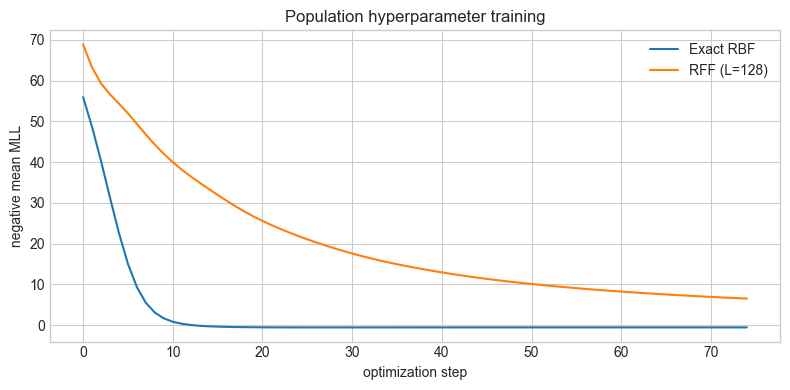

In [120]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(rbf_losses, label="Exact RBF")
ax.plot(rff_losses, label=f"RFF (L={L})")
ax.set(title="Population hyperparameter training", xlabel="optimization step", ylabel="negative mean MLL")
ax.legend()
fig.tight_layout()
plt.show()

## Learnable symmetric spectral RFF models

We now replace the zero-centered RBF spectrum with the spectral family that generated the periodic signals. For one component, use the symmetric density

$$p_a(\omega)=\tfrac12\mathcal N(\omega;\omega_a,s_a^2)+\tfrac12\mathcal N(\omega;-\omega_a,s_a^2).$$

By Bochner's theorem its exact kernel is

$$k_a(\tau)=\sigma_f^2\exp(-s_a^2\tau^2/2)\cos(\omega_a\tau).$$

For the RFF approximation, draw fixed $\epsilon_d\sim\mathcal N(0,1)$ and reparameterize $\nu_d=\omega_a+s_a\epsilon_d$. Then use

$$z_a(x)=\sqrt{\frac1D}[\cos(\nu_1x),\sin(\nu_1x),\ldots,\cos(\nu_Dx),\sin(\nu_Dx)]^\top.$$

Although frequencies are written around $+\omega_a$, each sine/cosine pair estimates $\cos(\nu_d(x-x'))$ and therefore implicitly represents the symmetric $\pm\omega_a$ density. The Gaussian draws remain fixed while both $\omega_a$ and the positive variance $s_a^2$ are learned through the differentiable reparameterization.

The fit is initialized at unit variance, $s_a^2=1$, but the variance is now learnable. The database has $\ell=0.6$, hence the target spectral variance is $\ell^{-2}\approx2.7778$.

In [121]:
def gaussian_density(omega, mean, variance):
    return np.exp(-0.5 * (omega - mean) ** 2 / variance) / np.sqrt(2 * np.pi * variance)


def kernel_on_lags(model, lag_values):
    parameter = next(model.parameters())
    lag_tensor = torch.as_tensor(lag_values, dtype=parameter.dtype).unsqueeze(-1)
    zero_tensor = torch.zeros((1, 1), dtype=parameter.dtype)
    model.eval()
    with torch.no_grad():
        values = model.covar_module(lag_tensor, zero_tensor).to_dense().squeeze(-1)
    return values.cpu().numpy()


single_component = 0
single_curves = train_curves[train_labels == single_component]
single_x_tensor, single_curves_tensor = as_gp_tensors(x, single_curves)
initial_spectral_variance = 1.0

single_spectral_model, single_spectral_likelihood = build_symmetric_spectral_mixture_rff_gp(
    single_x_tensor,
    single_curves_tensor,
    initial_component_means=torch.tensor([5.0]),
    num_frequencies_per_component=128,
    spectral_variance=initial_spectral_variance,
    learn_spectral_variance=True,
    seed=seed + 20,
    initial_outputscale=1.0,
    initial_noise=noise_std**2,
)
single_spectral_losses = train_shared_gp(
    single_spectral_model,
    single_spectral_likelihood,
    single_x_tensor,
    single_curves_tensor,
    num_steps=400,
    learning_rate=0.03,
    print_every=100,
)
single_spectral_parameters = learned_spectral_mixture_parameters(
    single_spectral_model, single_spectral_likelihood
)
single_spectral_parameters

step    1/400 | loss=9.2323 | spectral_means=[5.03] | variances=[1.019] | weights=[1.] | noise=0.00258
step  100/400 | loss=-0.7823 | spectral_means=[6.087] | variances=[1.962] | weights=[1.] | noise=0.00636
step  200/400 | loss=-0.9725 | spectral_means=[6.242] | variances=[2.376] | weights=[1.] | noise=0.00550
step  300/400 | loss=-1.0856 | spectral_means=[6.289] | variances=[2.74] | weights=[1.] | noise=0.00419
step  400/400 | loss=-1.1657 | spectral_means=[6.311] | variances=[3.087] | weights=[1.] | noise=0.00324


{'mean': -0.008304028771817684,
 'component_means': array([6.310726], dtype=float32),
 'mixture_weights': array([1.], dtype=float32),
 'spectral_variances': array([3.0871334], dtype=float32),
 'outputscale': 2.512225389480591,
 'noise': 0.0032388605177402496}

,true generator,learnable-variance RFF fit
quantity,,
positive spectral center,6.28319,6.31073
spectral variance,2.77778,3.08713
mixture weight,1.00000,1.00000


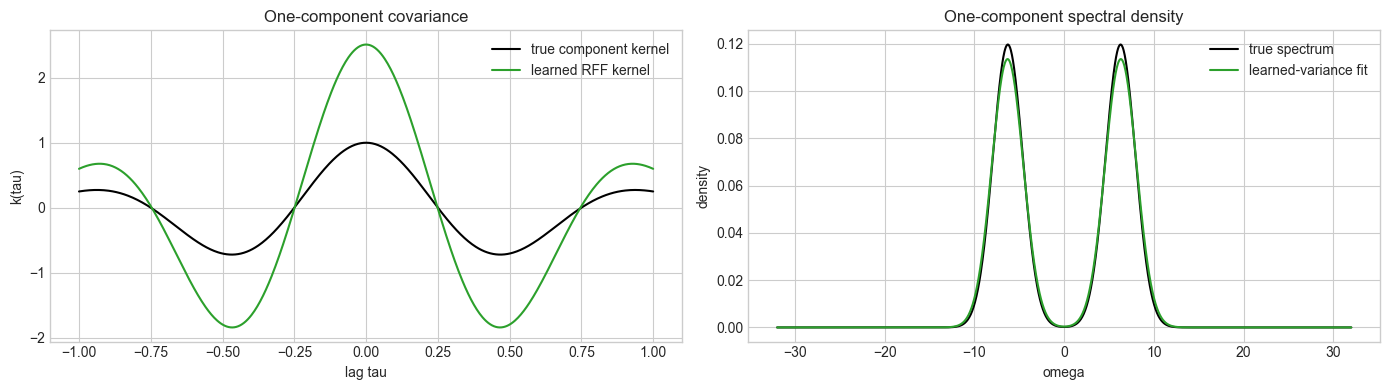

In [122]:
comparison_lags = np.linspace(-1.0, 1.0, 600)
spectral_grid = np.linspace(-32.0, 32.0, 1600)
true_center = frequencies[single_component]
learned_center = single_spectral_parameters["component_means"][0]
learned_spectral_variance = single_spectral_parameters["spectral_variances"][0]
true_spectral_variance = lengthscales[single_component] ** -2

true_component_kernel = np.exp(
    -comparison_lags**2 / (2 * lengthscales[single_component] ** 2)
) * np.cos(true_center * comparison_lags)
learned_component_kernel = kernel_on_lags(single_spectral_model, comparison_lags)
true_component_spectrum = 0.5 * (
    gaussian_density(spectral_grid, true_center, true_spectral_variance)
    + gaussian_density(spectral_grid, -true_center, true_spectral_variance)
)
learned_single_spectrum = 0.5 * (
    gaussian_density(spectral_grid, learned_center, learned_spectral_variance)
    + gaussian_density(spectral_grid, -learned_center, learned_spectral_variance)
)

single_recovery_table = pd.DataFrame({
    "quantity": ["positive spectral center", "spectral variance", "mixture weight"],
    "true generator": [true_center, true_spectral_variance, 1.0],
    "learnable-variance RFF fit": [learned_center, learned_spectral_variance, 1.0],
}).set_index("quantity")
display(single_recovery_table.style.format(precision=5).set_caption(
    "One-component symmetric spectral recovery"
))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(comparison_lags, true_component_kernel, color="black", label="true component kernel")
axes[0].plot(comparison_lags, learned_component_kernel, color="C2", label="learned RFF kernel")
axes[0].set(title="One-component covariance", xlabel="lag tau", ylabel="k(tau)")
axes[0].legend()
axes[1].plot(spectral_grid, true_component_spectrum, color="black", label="true spectrum")
axes[1].plot(spectral_grid, learned_single_spectrum, color="C2", label="learned-variance fit")
axes[1].set(title="One-component spectral density", xlabel="omega", ylabel="density")
axes[1].legend()
fig.tight_layout()
plt.show()

### Three-component spectral mixture with learnable weights

For $Q=3$ components, use

$$p_\theta(\omega)=\sum_{q=1}^3\rho_q\left[\tfrac12\mathcal N(\omega;\mu_q,s_q^2)+\tfrac12\mathcal N(\omega;-\mu_q,s_q^2)\right],$$

where $\rho_q=\operatorname{softmax}(\alpha)_q$, so $\rho_q>0$ and $\sum_q\rho_q=1$. The corresponding exact kernel family is

$$k_\theta(\tau)=\sigma_f^2\sum_{q=1}^3\rho_q\exp(-s_q^2\tau^2/2)\cos(\mu_q\tau).$$

We learn the three positive centers $\mu_q$, three positive spectral variances $s_q^2$, the three softmax weights $\rho_q$, the output scale, mean, and noise. Every variance is initialized at $1$ without giving the model the true value $\ell^{-2}$.

In [123]:
initial_mixture_spectral_variances = torch.ones(3)
initial_spectral_centers = torch.tensor([6.0, 12.0, 24.0])

spectral_mixture_model, spectral_mixture_likelihood = build_symmetric_spectral_mixture_rff_gp(
    train_x_tensor,
    train_curves_tensor,
    initial_component_means=initial_spectral_centers,
    num_frequencies_per_component=128,
    spectral_variance=initial_mixture_spectral_variances,
    learn_spectral_variance=True,
    initial_weights=torch.full((3,), 1 / 3),
    seed=seed + 24,
    initial_outputscale=1.0,
    initial_noise=noise_std**2,
)
spectral_mixture_losses = train_shared_gp(
    spectral_mixture_model,
    spectral_mixture_likelihood,
    train_x_tensor,
    train_curves_tensor,
    num_steps=1000,
    learning_rate=0.025,
    print_every=250,
)
spectral_mixture_parameters = learned_spectral_mixture_parameters(
    spectral_mixture_model, spectral_mixture_likelihood
)
spectral_mixture_parameters

step    1/1000 | loss=1.6732 | spectral_means=[ 5.975 12.025 24.025] | variances=[1.016 1.016 1.016] | weights=[0.328 0.328 0.345] | noise=0.00256
step  250/1000 | loss=-0.8416 | spectral_means=[ 5.914 13.121 25.2  ] | variances=[2.044 2.067 2.122] | weights=[0.278 0.333 0.39 ] | noise=0.00264
step  500/1000 | loss=-0.8551 | spectral_means=[ 6.248 13.039 25.327] | variances=[2.476 2.313 2.452] | weights=[0.325 0.32  0.356] | noise=0.00256
step  750/1000 | loss=-0.8582 | spectral_means=[ 6.38  12.908 25.321] | variances=[2.731 2.513 2.637] | weights=[0.331 0.318 0.352] | noise=0.00254
step 1000/1000 | loss=-0.8588 | spectral_means=[ 6.381 12.824 25.304] | variances=[2.763 2.62  2.736] | weights=[0.332 0.321 0.347] | noise=0.00254


{'mean': -0.0015631548594683409,
 'component_means': array([ 6.380711, 12.823863, 25.30374 ], dtype=float32),
 'mixture_weights': array([0.33172587, 0.32113117, 0.34714293], dtype=float32),
 'spectral_variances': array([2.7629707, 2.6196995, 2.7355363], dtype=float32),
 'outputscale': 1.139204740524292,
 'noise': 0.002535308012738824}

,true positive center,learned positive center,true spectral variance,learned spectral variance,population weight,empirical training share,learned weight
component,,,,,,,
0,6.28319,6.38071,2.77778,2.76297,0.33333,0.31250,0.33173
1,12.56637,12.82386,2.77778,2.61970,0.33333,0.35000,0.32113
2,25.13274,25.30374,2.77778,2.73554,0.33333,0.33750,0.34714


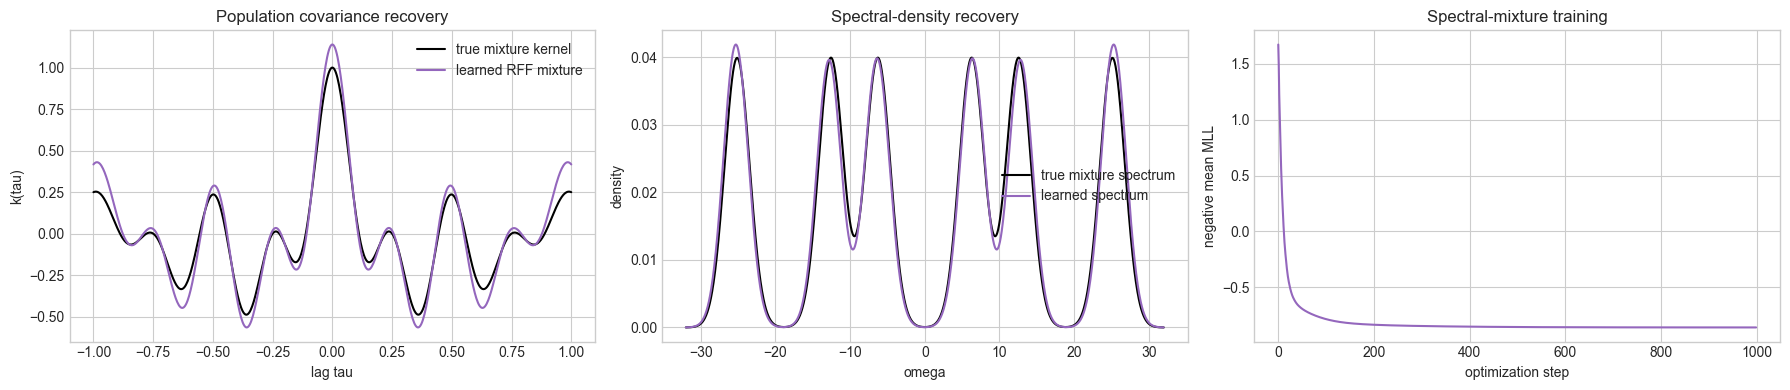

Finite data and finite RFF sampling mean exact numerical recovery is not expected; compare learned weights with both the population weights and empirical training shares.


In [124]:
learned_order = np.argsort(spectral_mixture_parameters["component_means"])
learned_centers = spectral_mixture_parameters["component_means"][learned_order]
learned_weights = spectral_mixture_parameters["mixture_weights"][learned_order]
learned_variances = spectral_mixture_parameters["spectral_variances"][learned_order]
empirical_train_weights = np.bincount(train_labels, minlength=3) / len(train_labels)

mixture_recovery_table = pd.DataFrame({
    "component": np.arange(3),
    "true positive center": frequencies,
    "learned positive center": learned_centers,
    "true spectral variance": np.full(3, true_spectral_variance),
    "learned spectral variance": learned_variances,
    "population weight": mixture_weights,
    "empirical training share": empirical_train_weights,
    "learned weight": learned_weights,
}).set_index("component")
display(mixture_recovery_table.style.format(precision=5).set_caption(
    "Recovery of the three spectral bands and mixture weights"
))

true_mixture_kernel = sum(
    mixture_weights[q]
    * np.exp(-comparison_lags**2 / (2 * lengthscales[q] ** 2))
    * np.cos(frequencies[q] * comparison_lags)
    for q in range(3)
)
learned_mixture_kernel = kernel_on_lags(spectral_mixture_model, comparison_lags)
true_mixture_spectrum = sum(
    0.5 * mixture_weights[q]
    * (gaussian_density(spectral_grid, frequencies[q], true_spectral_variance)
       + gaussian_density(spectral_grid, -frequencies[q], true_spectral_variance))
    for q in range(3)
)
learned_mixture_spectrum = sum(
    0.5 * learned_weights[q]
    * (gaussian_density(spectral_grid, learned_centers[q], learned_variances[q])
       + gaussian_density(spectral_grid, -learned_centers[q], learned_variances[q]))
    for q in range(3)
)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
axes[0].plot(comparison_lags, true_mixture_kernel, color="black", label="true mixture kernel")
axes[0].plot(comparison_lags, learned_mixture_kernel, color="C4", label="learned RFF mixture")
axes[0].set(title="Population covariance recovery", xlabel="lag tau", ylabel="k(tau)")
axes[0].legend()
axes[1].plot(spectral_grid, true_mixture_spectrum, color="black", label="true mixture spectrum")
axes[1].plot(spectral_grid, learned_mixture_spectrum, color="C4", label="learned spectrum")
axes[1].set(title="Spectral-density recovery", xlabel="omega", ylabel="density")
axes[1].legend()
axes[2].plot(spectral_mixture_losses, color="C4")
axes[2].set(title="Spectral-mixture training", xlabel="optimization step", ylabel="negative mean MLL")
fig.tight_layout()
plt.show()

print(
    "Finite data and finite RFF sampling mean exact numerical recovery is not expected; "
    "compare learned weights with both the population weights and empirical training shares."
)

### Sparse observations from held-out signals

We randomly select several held-out signals and reveal only a small, random, non-uniform subset of locations from each one. Each model keeps its population hyperparameters fixed and conditions on exactly the same sparse observations. Shaded regions are approximate 95% predictive intervals, including observation noise.

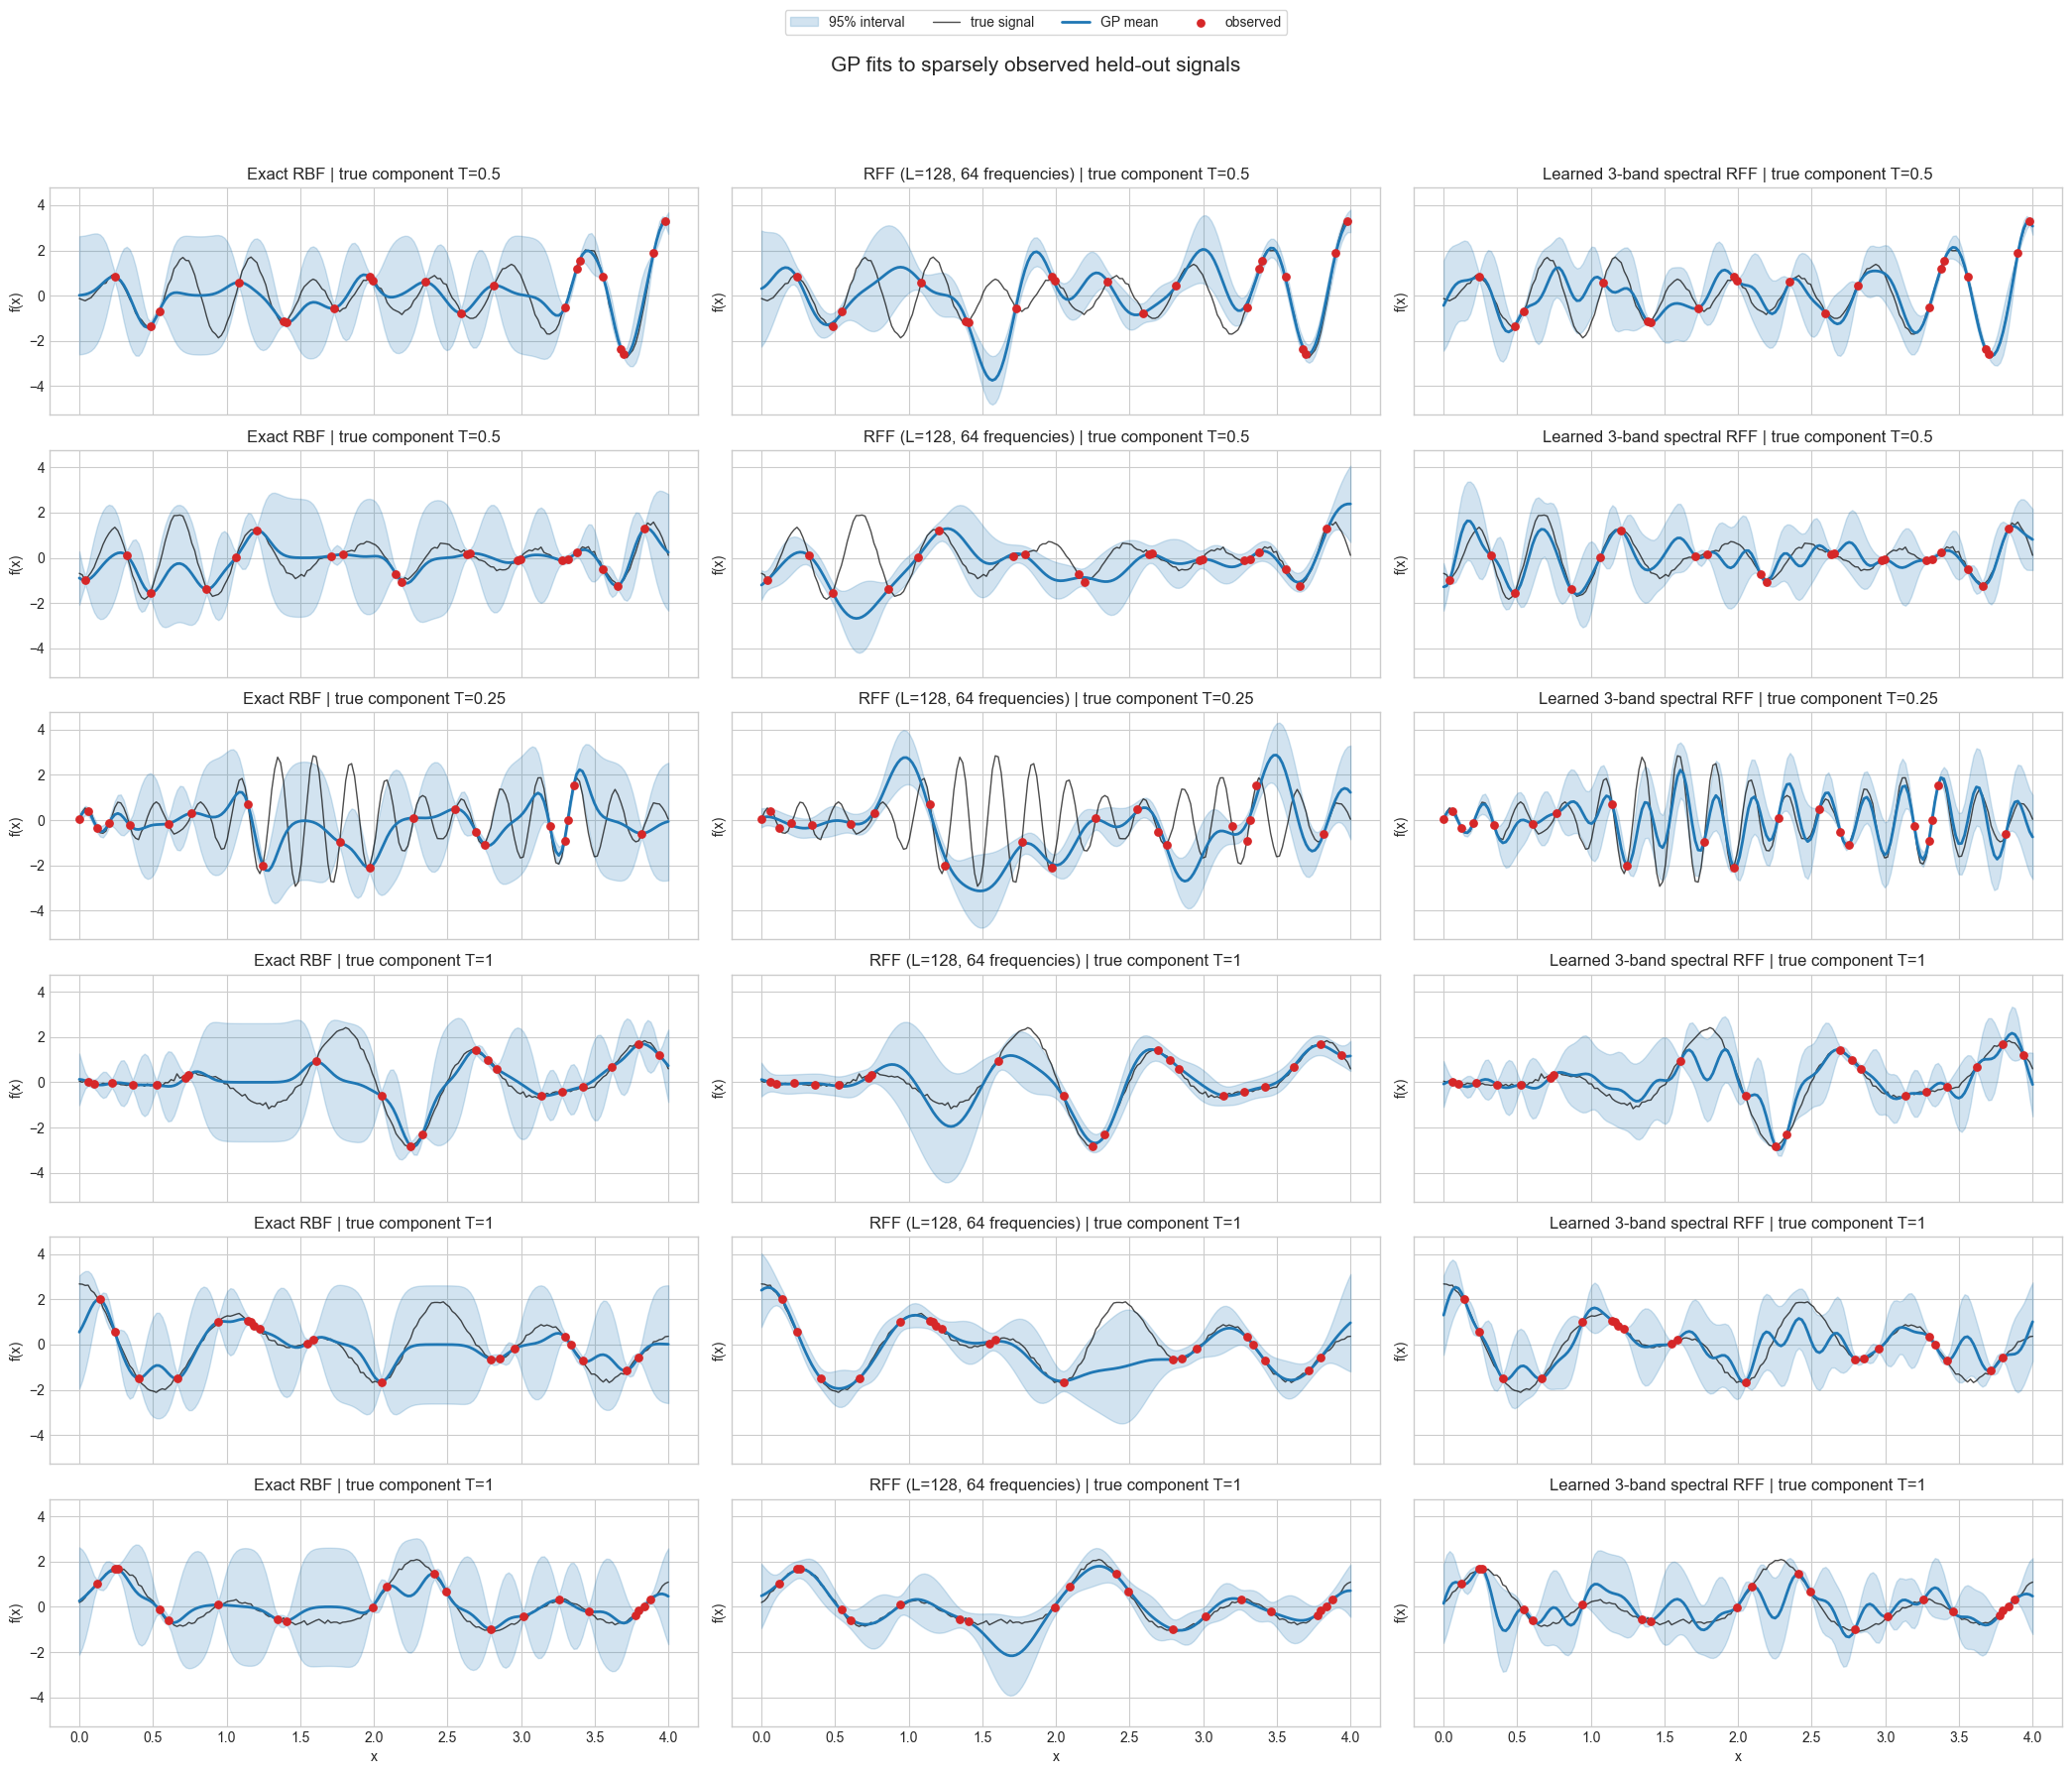

In [126]:
# Increase these two values to display more signals or reveal more observations.
n_test_signals_to_plot = 6
n_observations = 20
plot_rng = np.random.default_rng(seed + 4)
selected_test = plot_rng.choice(
    len(test_curves),
    size=min(n_test_signals_to_plot, len(test_curves)),
    replace=False,
)

models = [
    ("Exact RBF", rbf_model, rbf_likelihood),
    (f"RFF (L={L}, {L // 2} frequencies)", rff_model, rff_likelihood),
    ("Learned 3-band spectral RFF", spectral_mixture_model, spectral_mixture_likelihood),
]

fig, axes = plt.subplots(
    len(selected_test), len(models),
    figsize=(7.0 * len(models), 3.0 * len(selected_test)),
    sharex=True, sharey=True, squeeze=False,
)

for row, test_index in enumerate(selected_test):
    signal = test_curves[test_index]
    component = test_labels[test_index]
    # Draw different irregular observation locations for each test signal.
    observed_indices = np.sort(
        plot_rng.choice(len(x), size=min(n_observations, len(x)), replace=False)
    )
    observed_x = x[observed_indices]
    observed_y = signal[observed_indices]

    for col, (model_name, model, likelihood) in enumerate(models):
        prediction = predict_sparse_signal(
            model, likelihood, observed_x, observed_y, x
        )
        ax = axes[row, col]
        ax.fill_between(
            prediction.x, prediction.lower, prediction.upper,
            color="C0", alpha=0.2, label="95% interval"
        )
        ax.plot(x, signal, color="black", linewidth=1.0, alpha=0.7, label="true signal")
        ax.plot(prediction.x, prediction.mean, color="C0", linewidth=2.0, label="GP mean")
        ax.scatter(observed_x, observed_y, color="C3", s=28, zorder=5, label="observed")
        ax.set_title(f"{model_name} | true component T={periods[component]:g}")
        ax.set_ylabel("f(x)")

for ax in axes[-1]:
    ax.set_xlabel("x")
handles, legend_labels = axes[0, 0].get_legend_handles_labels()
fig.legend(
    handles, legend_labels,
    loc="upper center", bbox_to_anchor=(0.5, 0.995),
    ncol=4, frameon=True,
)
fig.suptitle("GP fits to sparsely observed held-out signals", y=0.965, fontsize=15)
# Keep the title and legend inside the canvas instead of letting tight_layout clip them.
fig.tight_layout(rect=(0.0, 0.0, 1.0, 0.93))
plt.show()

# Conclusions

1. **A categorical mixture of GPs creates a multimodal population spectrum.** Each signal is generated by one locally periodic component, but averaging over signals gives

   $$k_{\mathrm{population}}(\tau)=\sum_m\pi_m k_m(\tau),\qquad p_{\mathrm{population}}(\omega)=\sum_m\pi_m p_m(\omega).$$

   Therefore, multiple periodic behaviors appear as several symmetric frequency bands in the population spectrum.

2. **Bochner's theorem connects the covariance and spectral views.** The locally periodic factor

   $$\exp[-\tau^2/(2\ell_m^2)]\cos(\omega_m\tau)$$

   corresponds to two Gaussian spectral bands centered at $\pm\omega_m$. The center controls the preferred period, while spectral variance $\ell_m^{-2}$ controls the bandwidth and loss of long-range periodic coherence.

3. **A zero-centered RBF spectrum has the wrong inductive bias for this dataset.** A single RBF can learn one effective lengthscale, output scale, and noise level, but it cannot place mass at several nonzero frequencies. Its population-wide parameters are consequently a compromise between incompatible oscillatory components.

4. **Standard RFFs approximate a kernel; they do not automatically make it more expressive.** The first RFF model approximates the same zero-centered RBF kernel, so increasing $L$ reduces Monte Carlo error but does not introduce new spectral bands.

5. **A learnable symmetric spectral-mixture RFF model matches the structure of the data.** Learning positive band centers $\mu_q$, variances $s_q^2$, and softmax weights $\rho_q$ allows the model to recover the main frequency bands and approximate the population mixture kernel:

   $$p_\theta(\omega)=\sum_q\rho_q\left[\tfrac12\mathcal N(\omega;\mu_q,s_q^2)+\tfrac12\mathcal N(\omega;-\mu_q,s_q^2)\right].$$

6. **Population learning and per-signal prediction play different roles.** Hyperparameters are learned once from all training curves. For a held-out signal, those parameters are kept fixed and only its sparse observations are used for conditioning. The learned kernel supplies population-level prior knowledge when an individual curve has few observations.

### Limitations and extensions

- The shared model learns the population-average covariance; it does not infer which latent component generated a new signal.
- Learned values need not exactly equal the generating values because the training set and the RFF approximation are finite, and marginal-likelihood optimization can have local optima.
- More RFF frequencies reduce kernel approximation error at greater computational cost.
- A natural next step is a conditional or hierarchical spectral model that infers a signal-specific component, mixture weights, or spectral density.

> **Main takeaway:** spectral flexibility matters more than the choice between an exact kernel calculation and its RFF approximation. RFFs become especially useful when they approximate a spectral family capable of representing the frequencies present in the data.